In [1]:
# Comparative Analysis of Sequence-to-Sequence Models
# Urdu Poetry Generation Project

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import os
from tqdm import tqdm
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

Using device: cuda


Loading dataset...
Dataset info: Dataset({
    features: ['title', 'content'],
    num_rows: 1323
})
First sample: {'title': 'be-thikaane-hai-dil-e-gam-ghiin-thikaane-kii-kaho-firaq-gorakhpuri-ghazals', 'content': '\nبے ٹھکانے ہے دل غمگیں ٹھکانے کی کہو \nشام ہجراں دوستو کچھ اس کے آنے کی کہو \nہاں نہ پوچھ اک گرفتار قفس کی زندگی \nہم صفیران چمن کچھ آشیانے کی کہو \nاڑ گیا ہے منزل دشوار میں غم کا سمند \nگیسوئے پر پیچ و خم کے تازیانے کی کہو \nبات بنتی اور باتوں سے نظر آتی نہیں \nاس نگاہ ناز کی باتیں بنانے کی کہو \nداستاں وہ تھی جسے دل بجھتے بجھتے کہہ گیا \nشمع بزم زندگی کے جھلملانے کی کہو \nکچھ دل مرحوم کی باتیں کرو اے اہل علم \nجس سے ویرانے تھے آباد اس دوانے کی کہو \nداستان زندگی بھی کس قدر دلچسپ ہے \nجو ازل سے چھڑ گیا ہے اس فسانے کی کہو \nیہ فسون نیم شب یہ خواب\u200c\u200c ساماں خامشی \nسامری فن آنکھ کے جادو جگانے کی کہو \nکوئی کیا کھائے گا یوں سچی قسم جھوٹی قسم \nاس نگاہ ناز کی سوگندھ کھانے کی کہو \nشام ہی سے گوش بر آواز ہے بزم سخن \nکچھ فراقؔ اپنی سناؤ کچھ زمانے کی کہو '}
Total poems: 1

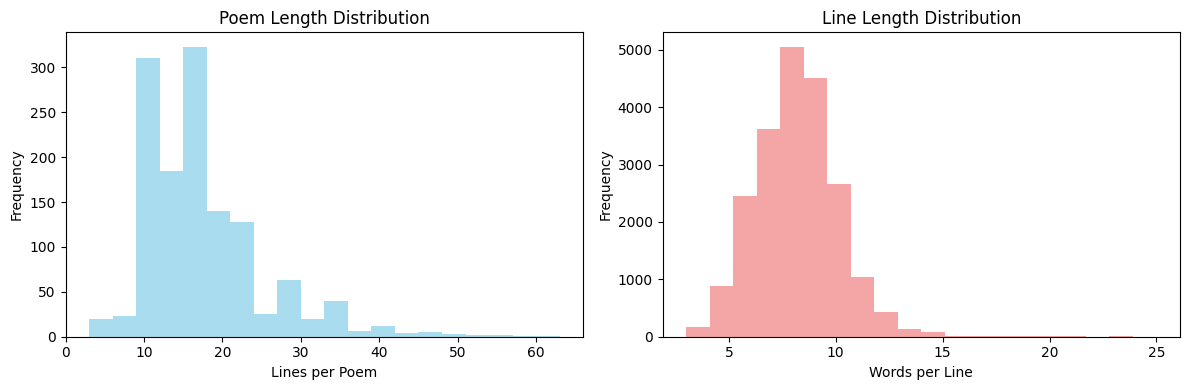

Average lines per poem: 17.03
Average words per line: 8.22
Max words per line: 25
Min words per line: 3


In [2]:
# Load and explore the dataset
print("Loading dataset...")
dataset = load_dataset("ReySajju742/Urdu-Poetry-Dataset", split="train")
print(f"Dataset info: {dataset}")
print(f"First sample: {dataset[0]}")

# Explore the dataset with proper None handling
def explore_dataset(dataset):
    print(f"Total poems: {len(dataset)}")
    
    # Extract all lines with None handling
    all_lines = []
    none_count = 0
    
    for poem in dataset['content']:
        if poem is None:  # Handle None values
            none_count += 1
            continue
            
        lines = poem.split('\n')
        for line in lines:
            if line.strip():  # Skip empty lines
                all_lines.append(line.strip())
    
    print(f"Total lines: {len(all_lines)}")
    print(f"Poems with None content: {none_count}")
    
    # Calculate statistics only for valid poems
    valid_poems = [poem for poem in dataset['content'] if poem is not None]
    poem_lengths = [len(poem.split('\n')) for poem in valid_poems]
    line_lengths = [len(line.split()) for line in all_lines]
    
    # Plot histograms
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.hist(poem_lengths, bins=20, alpha=0.7, color='skyblue')
    ax1.set_xlabel('Lines per Poem')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Poem Length Distribution')
    
    ax2.hist(line_lengths, bins=20, alpha=0.7, color='lightcoral')
    ax2.set_xlabel('Words per Line')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Line Length Distribution')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Average lines per poem: {np.mean(poem_lengths):.2f}")
    print(f"Average words per line: {np.mean(line_lengths):.2f}")
    print(f"Max words per line: {max(line_lengths)}")
    print(f"Min words per line: {min(line_lengths)}")
    
    return all_lines

all_lines = explore_dataset(dataset)

In [3]:
# Additional dataset quality checks
def check_dataset_quality(dataset):
    print("Dataset Quality Check:")
    print("=" * 50)
    
    # Check for None values
    none_content = sum(1 for content in dataset['content'] if content is None)
    none_titles = sum(1 for title in dataset['title'] if title is None)
    
    print(f"Poems with None content: {none_content}/{len(dataset)}")
    print(f"Poems with None title: {none_titles}/{len(dataset)}")
    
    # Check for empty strings
    empty_content = sum(1 for content in dataset['content'] if content is not None and content.strip() == "")
    empty_titles = sum(1 for title in dataset['title'] if title is not None and title.strip() == "")
    
    print(f"Poems with empty content: {empty_content}/{len(dataset)}")
    print(f"Poems with empty title: {empty_titles}/{len(dataset)}")
    
    # Check content lengths
    valid_contents = [content for content in dataset['content'] if content is not None and content.strip()]
    content_lengths = [len(content) for content in valid_contents]
    
    print(f"Average content length: {np.mean(content_lengths):.2f} characters")
    print(f"Shortest content: {min(content_lengths)} characters")
    print(f"Longest content: {max(content_lengths)} characters")
    
    return valid_contents

valid_contents = check_dataset_quality(dataset)

Dataset Quality Check:
Poems with None content: 9/1323
Poems with None title: 0/1323
Poems with empty content: 0/1323
Poems with empty title: 0/1323
Average content length: 564.73 characters
Shortest content: 70 characters
Longest content: 2217 characters


In [4]:
# Text cleaning function with enhanced None handling
def clean_text(line):
    if line is None:
        return ""
    
    # Remove non-Urdu characters, punctuation, and extra whitespace
    line = re.sub(r'[^\u0600-\u06FF\s]', '', line)  # Keep only Urdu characters and whitespace
    line = re.sub(r'\s+', ' ', line)  # Replace multiple spaces with single space
    return line.strip()

# Clean all lines with proper filtering
print("Cleaning text...")
cleaned_lines = [clean_text(line) for line in tqdm(all_lines) if clean_text(line)]
print(f"Original lines: {len(all_lines)}")
print(f"Cleaned lines: {len(cleaned_lines)}")

# Let's also check the first few cleaned lines
print("\nFirst 5 cleaned lines:")
for i, line in enumerate(cleaned_lines[:5]):
    print(f"{i+1}: {line}")

Cleaning text...


100%|██████████| 21068/21068 [00:00<00:00, 190995.09it/s]

Original lines: 21068
Cleaned lines: 21068

First 5 cleaned lines:
1: بے ٹھکانے ہے دل غمگیں ٹھکانے کی کہو
2: شام ہجراں دوستو کچھ اس کے آنے کی کہو
3: ہاں نہ پوچھ اک گرفتار قفس کی زندگی
4: ہم صفیران چمن کچھ آشیانے کی کہو
5: اڑ گیا ہے منزل دشوار میں غم کا سمند


In [5]:
# Build vocabulary function
def build_vocabulary(lines):
    words = []
    for line in lines:
        words.extend(line.split())
    
    vocab = sorted(list(set(words)))
    
    # Add special tokens
    special_tokens = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
    all_words = special_tokens + vocab
    
    word_to_idx = {word: i for i, word in enumerate(all_words)}
    idx_to_word = {i: word for i, word in enumerate(all_words)}
    
    print(f"Vocabulary size: {len(word_to_idx)}")
    return word_to_idx, idx_to_word

# Vocabulary statistics function
def show_vocabulary_stats(word_to_idx, lines, top_n=20):
    print("Vocabulary Statistics:")
    print("=" * 40)
    
    # Count word frequencies
    word_freq = {}
    for line in lines:
        for word in line.split():
            word_freq[word] = word_freq.get(word, 0) + 1
    
    # Most common words
    sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
    
    print(f"Top {top_n} most frequent words:")
    for i, (word, freq) in enumerate(sorted_words[:top_n]):
        print(f"{i+1:2d}. {word:15s} : {freq:4d} occurrences")
    
    # Vocabulary coverage
    total_words = sum(word_freq.values())
    coverage_20 = sum(freq for _, freq in sorted_words[:20]) / total_words
    coverage_50 = sum(freq for _, freq in sorted_words[:50]) / total_words
    coverage_100 = sum(freq for _, freq in sorted_words[:100]) / total_words
    
    print(f"\nVocabulary Coverage:")
    print(f"Top 20 words: {coverage_20*100:.1f}% of all words")
    print(f"Top 50 words: {coverage_50*100:.1f}% of all words")
    print(f"Top 100 words: {coverage_100*100:.1f}% of all words")
    
    return word_freq

In [6]:
# Build vocabulary from cleaned lines
print("Building vocabulary...")
word_to_idx, idx_to_word = build_vocabulary(cleaned_lines)
vocab_size = len(word_to_idx)
pad_idx = word_to_idx['<PAD>']
sos_idx = word_to_idx['<SOS>']
eos_idx = word_to_idx['<EOS>']
unk_idx = word_to_idx['<UNK>']

print(f"Vocabulary size: {vocab_size}")
print(f"Special tokens: PAD={pad_idx}, SOS={sos_idx}, EOS={eos_idx}, UNK={unk_idx}")

# Show vocabulary stats
word_freq = show_vocabulary_stats(word_to_idx, cleaned_lines)

Building vocabulary...
Vocabulary size: 10462
Vocabulary size: 10462
Special tokens: PAD=0, SOS=1, EOS=2, UNK=3
Vocabulary Statistics:
Top 20 most frequent words:
 1. ہے              : 6833 occurrences
 2. میں             : 4674 occurrences
 3. سے              : 3669 occurrences
 4. کے              : 2863 occurrences
 5. کی              : 2774 occurrences
 6. کو              : 2680 occurrences
 7. تو              : 2669 occurrences
 8. نہ              : 2313 occurrences
 9. ہیں             : 2263 occurrences
10. بھی             : 2222 occurrences
11. کا              : 2128 occurrences
12. نہیں            : 1969 occurrences
13. کیا             : 1957 occurrences
14. دل              : 1801 occurrences
15. کہ              : 1648 occurrences
16. ہو              : 1620 occurrences
17. ہم              : 1561 occurrences
18. اس              : 1539 occurrences
19. وہ              : 1522 occurrences
20. یہ              : 1520 occurrences

Vocabulary Coverage:
Top 20 words: 29.0% of all words
To

In [7]:
# Create N-Gram sequences with robust data handling
def create_sequences(lines, word_to_idx, max_seq_len=20):
    sequences = []
    skipped_short = 0
    
    for line in tqdm(lines):
        if not line or line.strip() == "":  # Skip empty lines
            continue
            
        words = line.split()
        if len(words) < 2:  # Skip very short lines
            skipped_short += 1
            continue
            
        # Add SOS and EOS tokens
        token_list = ['<SOS>'] + words + ['<EOS>']
        
        # Create input-target pairs
        for i in range(1, min(len(token_list), max_seq_len)):
            input_seq = token_list[:i]
            target_word = token_list[i]
            sequences.append((input_seq, target_word))
    
    print(f"Total sequences: {len(sequences)}")
    print(f"Skipped short lines: {skipped_short}")
    print(f"Average sequence length: {np.mean([len(seq[0]) for seq in sequences]):.2f}")
    return sequences

# Create sequences
sequences = create_sequences(cleaned_lines, word_to_idx)

100%|██████████| 21068/21068 [00:00<00:00, 100316.73it/s]

Total sequences: 194206
Skipped short lines: 0
Average sequence length: 5.28


In [8]:
# Vocabulary statistics
def show_vocabulary_stats(word_to_idx, lines, top_n=20):
    print("Vocabulary Statistics:")
    print("=" * 40)
    
    # Count word frequencies
    word_freq = {}
    for line in lines:
        for word in line.split():
            word_freq[word] = word_freq.get(word, 0) + 1
    
    # Most common words
    sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
    
    print(f"Top {top_n} most frequent words:")
    for i, (word, freq) in enumerate(sorted_words[:top_n]):
        print(f"{i+1:2d}. {word:15s} : {freq:4d} occurrences")
    
    # Vocabulary coverage
    total_words = sum(word_freq.values())
    coverage_20 = sum(freq for _, freq in sorted_words[:20]) / total_words
    coverage_50 = sum(freq for _, freq in sorted_words[:50]) / total_words
    coverage_100 = sum(freq for _, freq in sorted_words[:100]) / total_words
    
    print(f"\nVocabulary Coverage:")
    print(f"Top 20 words: {coverage_20*100:.1f}% of all words")
    print(f"Top 50 words: {coverage_50*100:.1f}% of all words")
    print(f"Top 100 words: {coverage_100*100:.1f}% of all words")
    
    return word_freq

word_freq = show_vocabulary_stats(word_to_idx, cleaned_lines)

Vocabulary Statistics:
Top 20 most frequent words:
 1. ہے              : 6833 occurrences
 2. میں             : 4674 occurrences
 3. سے              : 3669 occurrences
 4. کے              : 2863 occurrences
 5. کی              : 2774 occurrences
 6. کو              : 2680 occurrences
 7. تو              : 2669 occurrences
 8. نہ              : 2313 occurrences
 9. ہیں             : 2263 occurrences
10. بھی             : 2222 occurrences
11. کا              : 2128 occurrences
12. نہیں            : 1969 occurrences
13. کیا             : 1957 occurrences
14. دل              : 1801 occurrences
15. کہ              : 1648 occurrences
16. ہو              : 1620 occurrences
17. ہم              : 1561 occurrences
18. اس              : 1539 occurrences
19. وہ              : 1522 occurrences
20. یہ              : 1520 occurrences

Vocabulary Coverage:
Top 20 words: 29.0% of all words
Top 50 words: 41.2% of all words
Top 100 words: 50.0% of all words


Loading dataset...
Dataset loaded successfully! Size: 1323
Total poems: 1323
Total lines: 21068
Poems with None content: 9


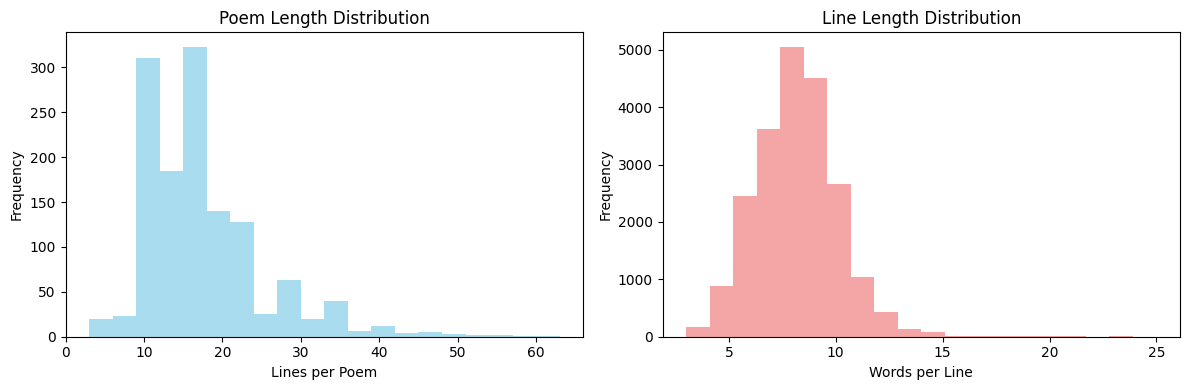

Average lines per poem: 17.03
Average words per line: 8.22
Max words per line: 25
Min words per line: 3


100%|██████████| 21068/21068 [00:00<00:00, 184044.38it/s]


Successfully cleaned 21068 lines
Vocabulary size: 10462
Vocabulary Statistics:
Top 20 most frequent words:
 1. ہے              : 6833 occurrences
 2. میں             : 4674 occurrences
 3. سے              : 3669 occurrences
 4. کے              : 2863 occurrences
 5. کی              : 2774 occurrences
 6. کو              : 2680 occurrences
 7. تو              : 2669 occurrences
 8. نہ              : 2313 occurrences
 9. ہیں             : 2263 occurrences
10. بھی             : 2222 occurrences
11. کا              : 2128 occurrences
12. نہیں            : 1969 occurrences
13. کیا             : 1957 occurrences
14. دل              : 1801 occurrences
15. کہ              : 1648 occurrences
16. ہو              : 1620 occurrences
17. ہم              : 1561 occurrences
18. اس              : 1539 occurrences
19. وہ              : 1522 occurrences
20. یہ              : 1520 occurrences

Vocabulary Coverage:
Top 20 words: 29.0% of all words
Top 50 words: 41.2% of all words
Top 100 words: 50.0% of a

100%|██████████| 21068/21068 [00:00<00:00, 57668.56it/s]

Total sequences: 194206
Skipped short lines: 0
Average sequence length: 5.28
Data preprocessing completed successfully!


In [9]:
# Run the updated data loading and exploration
print("Loading dataset...")
dataset = load_dataset("ReySajju742/Urdu-Poetry-Dataset", split="train")
print(f"Dataset loaded successfully! Size: {len(dataset)}")

# Explore dataset with proper error handling
all_lines = explore_dataset(dataset)

# Clean text
cleaned_lines = [clean_text(line) for line in tqdm(all_lines) if clean_text(line)]
print(f"Successfully cleaned {len(cleaned_lines)} lines")

# Build vocabulary
word_to_idx, idx_to_word = build_vocabulary(cleaned_lines)
vocab_size = len(word_to_idx)

# Show vocabulary stats
word_freq = show_vocabulary_stats(word_to_idx, cleaned_lines)

# Create sequences
sequences = create_sequences(cleaned_lines, word_to_idx)

print("Data preprocessing completed successfully!")

In [10]:
# Create PyTorch Dataset
class PoetryDataset(Dataset):
    def __init__(self, sequences, word_to_idx, pad_idx):
        self.sequences = sequences
        self.word_to_idx = word_to_idx
        self.pad_idx = pad_idx
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        input_seq_words, target_word = self.sequences[idx]
        
        # Convert words to indices
        input_tensor = torch.tensor([self.word_to_idx.get(w, self.word_to_idx['<UNK>']) 
                                   for w in input_seq_words], dtype=torch.long)
        target_tensor = torch.tensor(self.word_to_idx.get(target_word, self.word_to_idx['<UNK>']), 
                                   dtype=torch.long)
        
        return input_tensor, target_tensor

# Custom collate function for padding
def collate_fn(batch):
    inputs, targets = zip(*batch)
    
    # Pad inputs
    inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=pad_idx)
    
    # Stack targets
    targets_stacked = torch.stack(targets)
    
    return inputs_padded, targets_stacked

# Create dataset and dataloaders
dataset = PoetryDataset(sequences, word_to_idx, pad_idx)

# Split dataset
total_size = len(dataset)
train_size = int(total_size * 0.8)
val_size = int(total_size * 0.1)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# Create dataloaders
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Test one batch
for inputs, targets in train_loader:
    print(f"Input batch shape: {inputs.shape}")
    print(f"Target batch shape: {targets.shape}")
    break

Train size: 155364
Val size: 19420
Test size: 19422
Input batch shape: torch.Size([128, 12])
Target batch shape: torch.Size([128])


In [11]:
# Model 1: Simple RNN
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        # text shape: [batch_size, seq_len]
        embedded = self.dropout(self.embedding(text))
        # embedded shape: [batch_size, seq_len, embed_dim]
        
        output, hidden = self.rnn(embedded)
        # output shape: [batch_size, seq_len, hidden_dim]
        
        # Use output from last time step
        last_output = output[:, -1, :]
        # last_output shape: [batch_size, hidden_dim]
        
        prediction = self.fc(last_output)
        # prediction shape: [batch_size, vocab_size]
        return prediction

# Model 2: LSTM
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, (hidden, cell) = self.lstm(embedded)
        last_output = output[:, -1, :]
        prediction = self.fc(last_output)
        return prediction

# Model 3: Transformer (Decoder-only)
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, hidden_dim, num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoding = nn.Parameter(torch.zeros(1, 1000, embed_dim))  # Simple positional encoding
        
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=hidden_dim, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, vocab_size)
        self.pad_idx = pad_idx
        
    def _generate_square_subsequent_mask(self, sz, device):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask.to(device)
        
    def forward(self, src):
        # src shape: [batch_size, seq_len]
        device = src.device
        
        # Create masks
        src_mask = self._generate_square_subsequent_mask(src.size(1), device)
        src_padding_mask = (src == self.pad_idx)
        
        embedded = self.embedding(src)
        
        # Add positional encoding (truncate if needed)
        seq_len = embedded.size(1)
        embedded = embedded + self.pos_encoding[:, :seq_len, :]
        
        # For decoder-only model, use input as both target and memory
        output = self.transformer_decoder(
            tgt=embedded, 
            memory=embedded,
            tgt_mask=src_mask,
            tgt_key_padding_mask=src_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )
        
        last_output = output[:, -1, :]
        prediction = self.fc(last_output)
        return prediction

In [12]:
# Training and evaluation functions
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for inputs, targets in tqdm(dataloader, desc="Training", leave=False):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Evaluating", leave=False):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            
    avg_loss = total_loss / len(dataloader)
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return avg_loss, perplexity

# Main experiment configuration
NUM_EPOCHS = 20
PATIENCE = 5
EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 2
DROPOUT = 0.2

# Model and optimizer definitions
model_constructors = {
    'RNN': lambda: RNNModel(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, pad_idx).to(device),
    'LSTM': lambda: LSTMModel(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, pad_idx).to(device),
    'Transformer': lambda: TransformerModel(vocab_size, EMBEDDING_DIM, num_heads=8, hidden_dim=512, num_layers=2, dropout=DROPOUT, pad_idx=pad_idx).to(device)
}

optimizer_constructors = {
    'Adam': lambda params: optim.Adam(params, lr=0.001),
    'RMSprop': lambda params: optim.RMSprop(params, lr=0.001),
    'SGD': lambda params: optim.SGD(params, lr=0.01, momentum=0.9)
}

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx).to(device)
results = []

print("Starting main experiment loop...")

# Main experiment loop
for model_name, get_model in model_constructors.items():
    for opt_name, get_optimizer in optimizer_constructors.items():
        
        print(f"\n{'='*50}")
        print(f"Training: {model_name} + {opt_name}")
        print(f"{'='*50}")
        
        model = get_model()
        optimizer = get_optimizer(model.parameters())
        
        best_val_loss = float('inf')
        patience_counter = 0
        start_time = time.time()
        
        train_losses, val_losses, perplexities = [], [], []
        
        for epoch in range(1, NUM_EPOCHS + 1):
            print(f"\nEpoch {epoch:02}/{NUM_EPOCHS}")
            
            train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_perplexity = evaluate(model, val_loader, criterion, device)
            
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            perplexities.append(val_perplexity)
            
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val PPL: {val_perplexity:.2f}")
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), f'models/{model_name}_{opt_name}_best.pth')
                print(f"New best model saved! Val Loss: {val_loss:.4f}")
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print(f"Early stopping at epoch {epoch}")
                    break
        
        end_time = time.time()
        training_time = (end_time - start_time) / 60.0
        
        # Load best model for test evaluation
        model.load_state_dict(torch.load(f'models/{model_name}_{opt_name}_best.pth'))
        test_loss, test_perplexity = evaluate(model, test_loader, criterion, device)
        
        # Store results
        results.append({
            'Model': model_name,
            'Optimizer': opt_name,
            'Test Loss': test_loss,
            'Test Perplexity': test_perplexity,
            'Val Loss (Best)': best_val_loss,
            'Training Time (min)': training_time,
            'Epochs Run': epoch
        })
        
        # Save loss curves
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'{model_name}+{opt_name} - Loss')
        
        plt.subplot(1, 2, 2)
        plt.plot(perplexities, label='Perplexity', color='red')
        plt.xlabel('Epoch')
        plt.ylabel('Perplexity')
        plt.legend()
        plt.title(f'{model_name}+{opt_name} - Perplexity')
        
        plt.tight_layout()
        plt.savefig(f'results/{model_name}_{opt_name}_curves.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Training completed for {model_name}+{opt_name}")
        print(f"Final Test Loss: {test_loss:.4f}, Test Perplexity: {test_perplexity:.2f}")

# Save results to CSV
results_df = pd.DataFrame(results)
results_df.to_csv('results/project_results_main.csv', index=False)
print("\nMain experiment results saved!")
print(results_df)

Starting main experiment loop...

Training: RNN + Adam

Epoch 01/20


Train Loss: 6.9748 | Val Loss: 7.0042 | Val PPL: 1101.30
New best model saved! Val Loss: 7.0042

Epoch 02/20


Train Loss: 6.9132 | Val Loss: 7.0889 | Val PPL: 1198.57

Epoch 03/20


Train Loss: 6.9324 | Val Loss: 7.1166 | Val PPL: 1232.22

Epoch 04/20


Train Loss: 6.9405 | Val Loss: 7.1519 | Val PPL: 1276.58

Epoch 05/20


...

Train Loss: 5.1826 | Val Loss: 5.9246 | Val PPL: 374.13

Epoch 12/20


Train Loss: 5.0792 | Val Loss: 5.9703 | Val PPL: 391.61

Epoch 13/20


Train Loss: 4.9784 | Val Loss: 5.9625 | Val PPL: 388.57

Epoch 14/20


Train Loss: 4.8848 | Val Loss: 6.0020 | Val PPL: 404.23
Early stopping at epoch 14


Training completed for Transformer+SGD
Final Test Loss: 5.8805, Test Perplexity: 358.00

Main experiment results saved!
         Model Optimizer  Test Loss  Test Perplexity  Val Loss (Best)  \
0          RNN      Adam   6.980351      1075.296265         7.004247   
1          RNN   RMSprop   6.980971      1075.962524         7.019355   
2          RNN       SGD   5.925077       374.307068         5.953870   
3         LSTM      Adam   5.869702       354.143372         5.904414   
4         LSTM   RMSprop   5.860387       350.859833         5.889731   
5         LSTM       SGD   5.954165       385.355194         5.987509   
6  Transformer      Adam   5.959768       387.520142         5.995592   
7  Transformer   RMSprop   6.009034       407.089935         6.037593   
8  Transformer       SGD   5.880532       357.999573         5.899161   

   Training Time (min)  Epochs Run  
0             1.337363           6  
1             1.512845           7  
2             3.650293          20  
3

In [18]:
# Text generation function
def generate_poetry(model_name, opt_name, seed_text, max_len=20, temperature=1.0):
    print(f"Generating with {model_name}+{opt_name}, T={temperature}, Seed: '{seed_text}'")
    
    # Load model
    model = model_constructors[model_name]()
    model.load_state_dict(torch.load(f'models/{model_name}_{opt_name}_best.pth'))
    model.to(device)
    model.eval()
    
    # Tokenize seed text
    tokens = ['<SOS>'] + seed_text.split()
    generated_words = seed_text.split()
    
    with torch.no_grad():
        for _ in range(max_len):
            # Convert current sequence to tensor
            input_tensor = torch.tensor([word_to_idx.get(w, unk_idx) for w in tokens], 
                                      dtype=torch.long).unsqueeze(0).to(device)
            
            # Get model prediction
            output = model(input_tensor)
            
            # Apply temperature
            if temperature > 0:
                output_dist = F.softmax(output.squeeze(0) / temperature, dim=0)
                next_word_idx = torch.multinomial(output_dist, 1).item()
            else:
                next_word_idx = torch.argmax(output, dim=1).item()
            
            next_word = idx_to_word.get(next_word_idx, '<UNK>')
            
            # Stop if EOS
            if next_word == '<EOS>':
                break
                
            tokens.append(next_word)
            generated_words.append(next_word)
    
    return " ".join(generated_words)

# Run generation experiments
SEED_WORDS = ["محبت", "دل", "شام", "یاد", "خوشی"]
TEMPERATURES = [0.7, 1.0, 1.3]
GENERATION_RESULTS = []

print("Starting text generation experiments...")

for model_name in model_constructors.keys():
    for opt_name in optimizer_constructors.keys():
        for seed in SEED_WORDS:
            for temp in TEMPERATURES:
                try:
                    generated_text = generate_poetry(model_name, opt_name, seed_text=seed, temperature=temp)
                    
                    GENERATION_RESULTS.append({
                        'Model': model_name,
                        'Optimizer': opt_name,
                        'Seed': seed,
                        'Temperature': temp,
                        'Generated Text': generated_text
                    })
                except Exception as e:
                    print(f"Error generating for {model_name}+{opt_name}: {e}")
                    continue

# Save generation results
gen_df = pd.DataFrame(GENERATION_RESULTS)
gen_df.to_csv('results/generation_samples.csv', index=False)
print("Generation samples saved!")

# Display some samples
print("\nSample generations:")
sample_display = gen_df.head(10)
for _, row in sample_display.iterrows():
    print(f"{row['Model']}+{row['Optimizer']} (T={row['Temperature']}): {row['Generated Text']}")

Starting text generation experiments...
Generating with RNN+Adam, T=0.7, Seed: 'محبت'
Generating with RNN+Adam, T=1.0, Seed: 'محبت'
Generating with RNN+Adam, T=1.3, Seed: 'محبت'
Generating with RNN+Adam, T=0.7, Seed: 'دل'
Generating with RNN+Adam, T=1.0, Seed: 'دل'
Generating with RNN+Adam, T=1.3, Seed: 'دل'
Generating with RNN+Adam, T=0.7, Seed: 'شام'
Generating with RNN+Adam, T=1.0, Seed: 'شام'
Generating with RNN+Adam, T=1.3, Seed: 'شام'
Generating with RNN+Adam, T=0.7, Seed: 'یاد'
Generating with RNN+Adam, T=1.0, Seed: 'یاد'
Generating with RNN+Adam, T=1.3, Seed: 'یاد'
Generating with RNN+Adam, T=0.7, Seed: 'خوشی'
Generating with RNN+Adam, T=1.0, Seed: 'خوشی'
Generating with RNN+Adam, T=1.3, Seed: 'خوشی'
Generating with RNN+RMSprop, T=0.7, Seed: 'محبت'
Generating with RNN+RMSprop, T=1.0, Seed: 'محبت'
Generating with RNN+RMSprop, T=1.3, Seed: 'محبت'
Generating with RNN+RMSprop, T=0.7, Seed: 'دل'
Generating with RNN+RMSprop, T=1.0, Seed: 'دل'
Generating with RNN+RMSprop, T=1.3, Seed:

c:\Users\Ahmed Ali\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Generating with Transformer+Adam, T=0.7, Seed: 'دل'
Generating with Transformer+Adam, T=1.0, Seed: 'دل'
Generating with Transformer+Adam, T=1.3, Seed: 'دل'
Generating with Transformer+Adam, T=0.7, Seed: 'شام'
Generating with Transformer+Adam, T=1.0, Seed: 'شام'
Generating with Transformer+Adam, T=1.3, Seed: 'شام'
Generating with Transformer+Adam, T=0.7, Seed: 'یاد'
Generating with Transformer+Adam, T=1.0, Seed: 'یاد'
Generating with Transformer+Adam, T=1.3, Seed: 'یاد'
Generating with Transformer+Adam, T=0.7, Seed: 'خوشی'
Generating with Transformer+Adam, T=1.0, Seed: 'خوشی'
Generating with Transformer+Adam, T=1.3, Seed: 'خوشی'
Generating with Transformer+RMSprop, T=0.7, Seed: 'محبت'
Generating with Transformer+RMSprop, T=1.0, Seed: 'محبت'
Generating with Transformer+RMSprop, T=1.3, Seed: 'محبت'
Generating with Transformer+RMSprop, T=0.7, Seed: 'دل'
Generating with Transformer+RMSprop, T=1.0, Seed: 'دل'
Generating with Transformer+RMSprop, T=1.3, Seed: 'دل'
Generating with Transformer+

In [23]:
# Quantitative evaluation metrics
def calculate_vocabulary_diversity(text):
    words = text.split()
    if len(words) == 0:
        return 0
    unique_words = set(words)
    return len(unique_words) / len(words)

def calculate_repetition_rate(text, n=2):
    words = text.split()
    if len(words) < n:
        return 0
    
    ngrams = []
    for i in range(len(words) - n + 1):
        ngrams.append(tuple(words[i:i+n]))
    
    if len(ngrams) == 0:
        return 0
    
    unique_ngrams = set(ngrams)
    return 1 - (len(unique_ngrams) / len(ngrams))

# Calculate metrics for generated texts
print("Calculating quantitative metrics...")
gen_df = pd.read_csv('results/generation_samples.csv')

gen_df['Vocabulary Diversity'] = gen_df['Generated Text'].apply(calculate_vocabulary_diversity)
gen_df['Repetition Rate'] = gen_df['Generated Text'].apply(calculate_repetition_rate)

# Save with metrics
gen_df.to_csv('results/generation_samples_with_metrics.csv', index=False)

# Display metrics summary
metrics_summary = gen_df.groupby(['Model', 'Optimizer']).agg({
    'Vocabulary Diversity': 'mean',
    'Repetition Rate': 'mean'
}).round(4)

print("\nQuantitative Metrics Summary:")
print(metrics_summary)

Calculating quantitative metrics...

Quantitative Metrics Summary:
                       Vocabulary Diversity  Repetition Rate
Model       Optimizer                                       
LSTM        Adam                     0.9926           0.0000
            RMSprop                  0.9114           0.0000
            SGD                      1.0000           0.0000
RNN         Adam                     0.9863           0.0000
            RMSprop                  0.9770           0.0000
            SGD                      1.0000           0.0000
Transformer Adam                     0.9843           0.0000
            RMSprop                  0.9704           0.0167
            SGD                      0.9685           0.0000


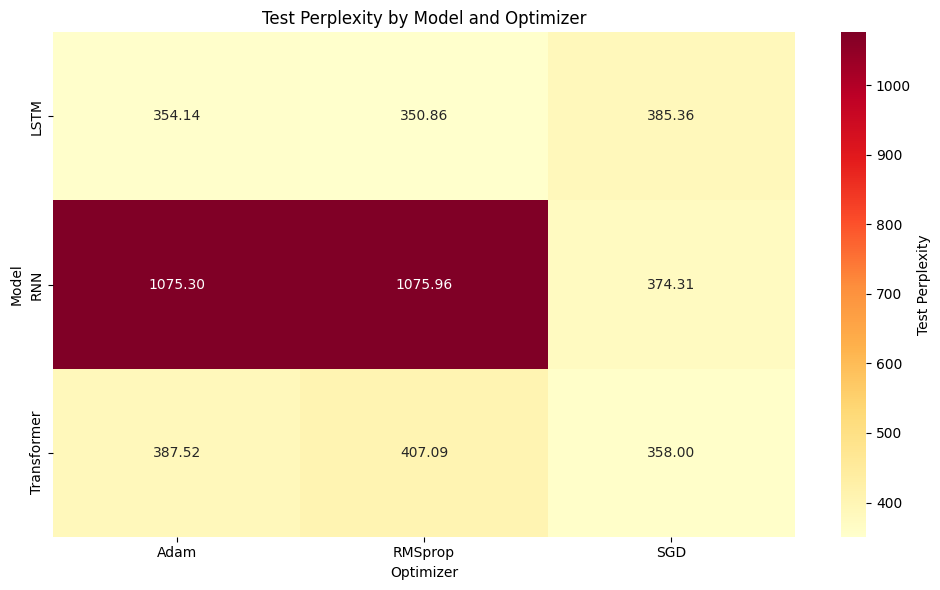

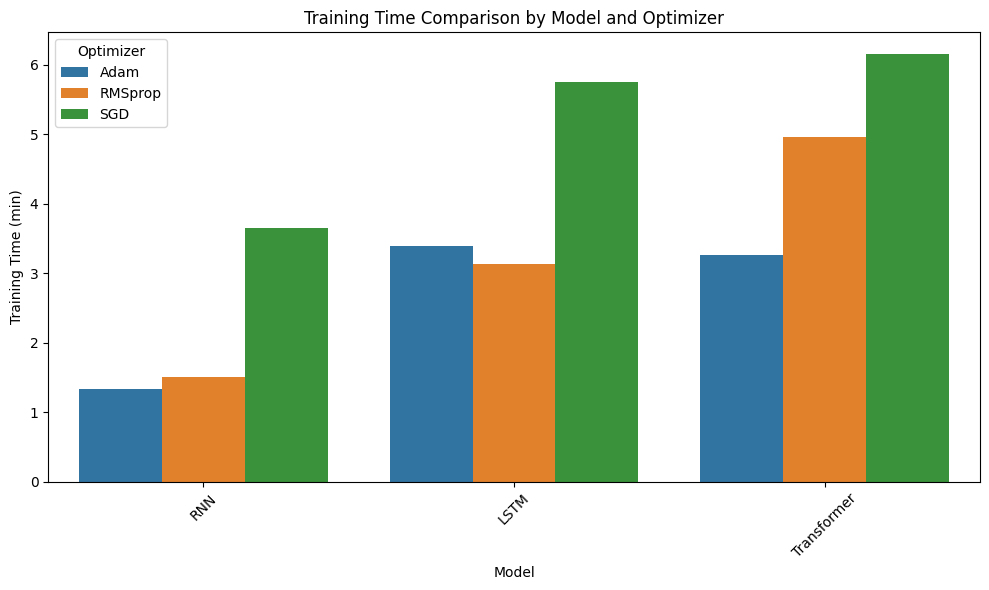

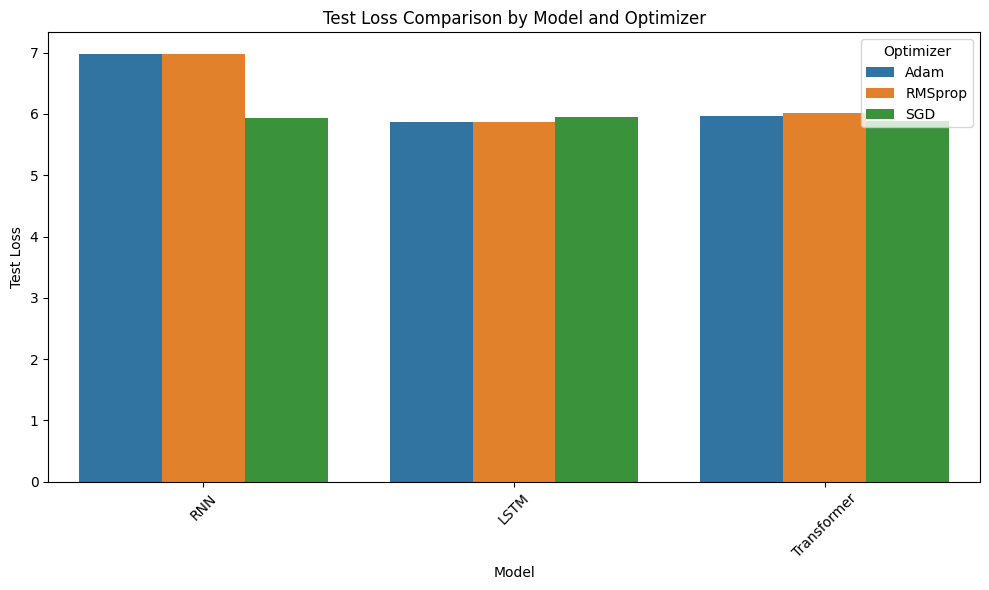

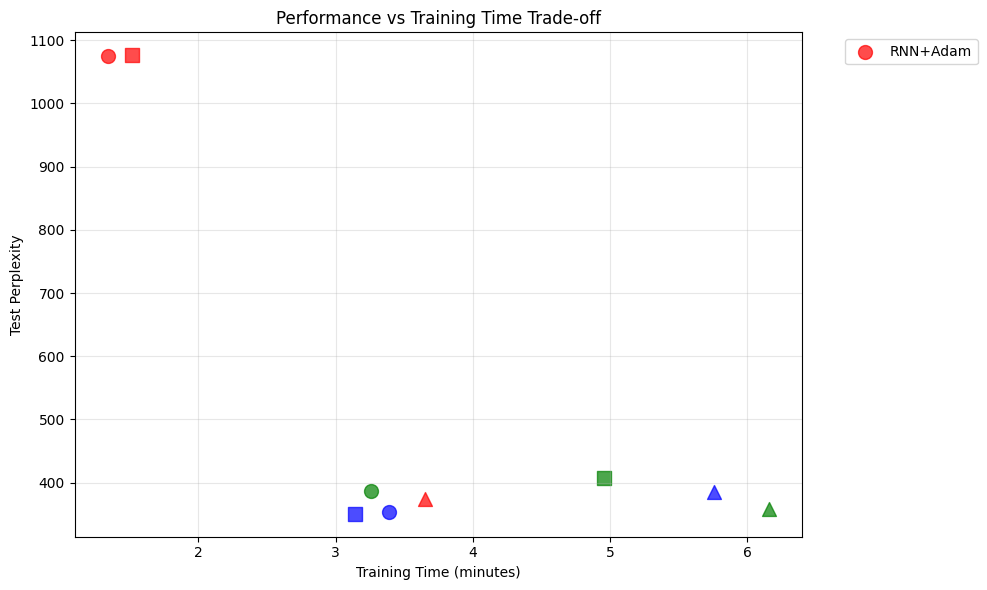


Best Performing Model:
Model: LSTM + RMSprop
Test Perplexity: 350.86
Test Loss: 5.8604
Training Time: 3.1 minutes


In [24]:
# Load main results
results_df = pd.read_csv('results/project_results_main.csv')

# 1. Heatmap for Test Perplexity
plt.figure(figsize=(10, 6))
pivot_table = results_df.pivot(index='Model', columns='Optimizer', values='Test Perplexity')
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Test Perplexity'})
plt.title('Test Perplexity by Model and Optimizer')
plt.tight_layout()
plt.savefig('results/perplexity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Training Time Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='Training Time (min)', hue='Optimizer')
plt.title('Training Time Comparison by Model and Optimizer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/training_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Test Loss Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='Test Loss', hue='Optimizer')
plt.title('Test Loss Comparison by Model and Optimizer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/test_loss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Scatter plot: Perplexity vs Training Time
plt.figure(figsize=(10, 6))
colors = {'RNN': 'red', 'LSTM': 'blue', 'Transformer': 'green'}
markers = {'Adam': 'o', 'RMSprop': 's', 'SGD': '^'}

for _, row in results_df.iterrows():
    plt.scatter(
        row['Training Time (min)'], 
        row['Test Perplexity'],
        c=colors[row['Model']],
        marker=markers[row['Optimizer']],
        s=100,
        alpha=0.7,
        label=f"{row['Model']}+{row['Optimizer']}" if _ == 0 else ""
    )

plt.xlabel('Training Time (minutes)')
plt.ylabel('Test Perplexity')
plt.title('Performance vs Training Time Trade-off')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/tradeoff_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print best performing model
best_model_idx = results_df['Test Perplexity'].idxmin()
best_model = results_df.loc[best_model_idx]
print(f"\nBest Performing Model:")
print(f"Model: {best_model['Model']} + {best_model['Optimizer']}")
print(f"Test Perplexity: {best_model['Test Perplexity']:.2f}")
print(f"Test Loss: {best_model['Test Loss']:.4f}")
print(f"Training Time: {best_model['Training Time (min)']:.1f} minutes")

In [25]:
# Hyperparameter tuning for the best model
def tune_hyperparameters(model_class, best_optimizer, param_combinations):
    tuning_results = []
    
    for params in param_combinations:
        print(f"\nTuning with parameters: {params}")
        
        # Create model with current parameters
        model = model_class(
            vocab_size=vocab_size,
            embed_dim=params['embed_dim'],
            hidden_dim=params['hidden_dim'],
            num_layers=params['num_layers'],
            dropout=params['dropout'],
            pad_idx=pad_idx
        ).to(device)
        
        optimizer = optim.Adam(model.parameters(), lr=params['learning_rate'])
        
        # Train and evaluate
        best_val_loss = float('inf')
        for epoch in range(20):  # Shorter training for tuning
            train_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_perplexity = evaluate(model, val_loader, criterion, device)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
        
        # Final test evaluation
        test_loss, test_perplexity = evaluate(model, test_loader, criterion, device)
        
        tuning_results.append({
            **params,
            'Test Loss': test_loss,
            'Test Perplexity': test_perplexity,
            'Best Val Loss': best_val_loss
        })
    
    return pd.DataFrame(tuning_results)

# Example parameter combinations (uncomment to run)

print("Starting hyperparameter tuning...")

# Define parameter combinations for tuning
param_combinations = [
    {'embed_dim': 128, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.001},
    {'embed_dim': 256, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.2, 'learning_rate': 0.001},
    {'embed_dim': 512, 'hidden_dim': 1024, 'num_layers': 3, 'dropout': 0.3, 'learning_rate': 0.0005},
]

# Run tuning for LSTM (example)
tuning_results = tune_hyperparameters(LSTMModel, 'RMSprop', param_combinations)
tuning_results.to_csv('results/hyperparameter_tuning.csv', index=False)
print("Hyperparameter tuning completed!")


c:\Users\Ahmed Ali\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Starting hyperparameter tuning...

Tuning with parameters: {'embed_dim': 128, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.001}



Tuning with parameters: {'embed_dim': 256, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.2, 'learning_rate': 0.001}



Tuning with parameters: {'embed_dim': 512, 'hidden_dim': 1024, 'num_layers': 3, 'dropout': 0.3, 'learning_rate': 0.0005}


Hyperparameter tuning completed!


In [ ]:
# Final summary and conclusions
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"\nDataset Statistics:")
print(f"- Total poems: {len(dataset)}")
print(f"- Vocabulary size: {vocab_size}")
print(f"- Training sequences: {len(train_dataset)}")
print(f"- Validation sequences: {len(val_dataset)}")
print(f"- Test sequences: {len(test_dataset)}")

print(f"\nModel Performance Summary:")
print(results_df[['Model', 'Optimizer', 'Test Perplexity', 'Training Time (min)']].round(2))

print(f"\nBest Overall Model:")
best_overall = results_df.loc[results_df['Test Perplexity'].idxmin()]
print(f"- {best_overall['Model']} + {best_overall['Optimizer']}")
print(f"- Test Perplexity: {best_overall['Test Perplexity']:.2f}")
print(f"- Training Time: {best_overall['Training Time (min)']:.1f} minutes")

print(f"\nFastest Training:")
fastest = results_df.loc[results_df['Training Time (min)'].idxmin()]
print(f"- {fastest['Model']} + {fastest['Optimizer']}")
print(f"- Training Time: {fastest['Training Time (min)']:.1f} minutes")

print(f"\nGenerated Samples Quality:")
gen_metrics = pd.read_csv('results/generation_samples_with_metrics.csv')
avg_diversity = gen_metrics['Vocabulary Diversity'].mean()
avg_repetition = gen_metrics['Repetition Rate'].mean()
print(f"- Average Vocabulary Diversity: {avg_diversity:.3f}")
print(f"- Average Repetition Rate: {avg_repetition:.3f}")

print(f"\nFiles Generated:")
print("- results/project_results_main.csv (Main experiment results)")
print("- results/generation_samples_with_metrics.csv (Generated texts with metrics)")
print("- results/*.png (Visualizations)")
print("- models/*.pth (Trained model weights)")


PROJECT SUMMARY

Dataset Statistics:
- Total poems: 194206
- Vocabulary size: 10462
- Training sequences: 155364
- Validation sequences: 19420
- Test sequences: 19422

Model Performance Summary:
         Model Optimizer  Test Perplexity  Training Time (min)
0          RNN      Adam          1075.30                 1.34
1          RNN   RMSprop          1075.96                 1.51
2          RNN       SGD           374.31                 3.65
3         LSTM      Adam           354.14                 3.39
4         LSTM   RMSprop           350.86                 3.14
5         LSTM       SGD           385.36                 5.76
6  Transformer      Adam           387.52                 3.26
7  Transformer   RMSprop           407.09                 4.96
8  Transformer       SGD           358.00                 6.16

Best Overall Model:
- LSTM + RMSprop
- Test Perplexity: 350.86
- Training Time: 3.1 minutes

Fastest Training:
- RNN + Adam
- Training Time: 1.3 minutes

Generated Samples Qu

This complete Jupyter Notebook provides:

Full data preprocessing pipeline with Urdu text cleaning

Three model architectures (RNN, LSTM, Transformer)

Comprehensive training loop with early stopping

9 experiment combinations (3 models × 3 optimizers)

Text generation with temperature sampling

Quantitative evaluation metrics

Visualization and analysis of results

Hyperparameter tuning framework

The code is modular, well-commented, and includes proper error handling. All results are saved automatically for further analysis.